## Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

from sklearn import metrics
from sklearn.metrics import accuracy_score, auc, confusion_matrix, roc_auc_score, roc_curve, recall_score

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\SUPARNA DEY\Downloads\python\Churn Modeling.csv")

In [4]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Data Understanding

In [16]:
df.shape

(10000, 14)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [18]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [19]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [20]:
#Decriptive statistics of the data including mean, std, min, max values.
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [21]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [22]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

## Data Visualization

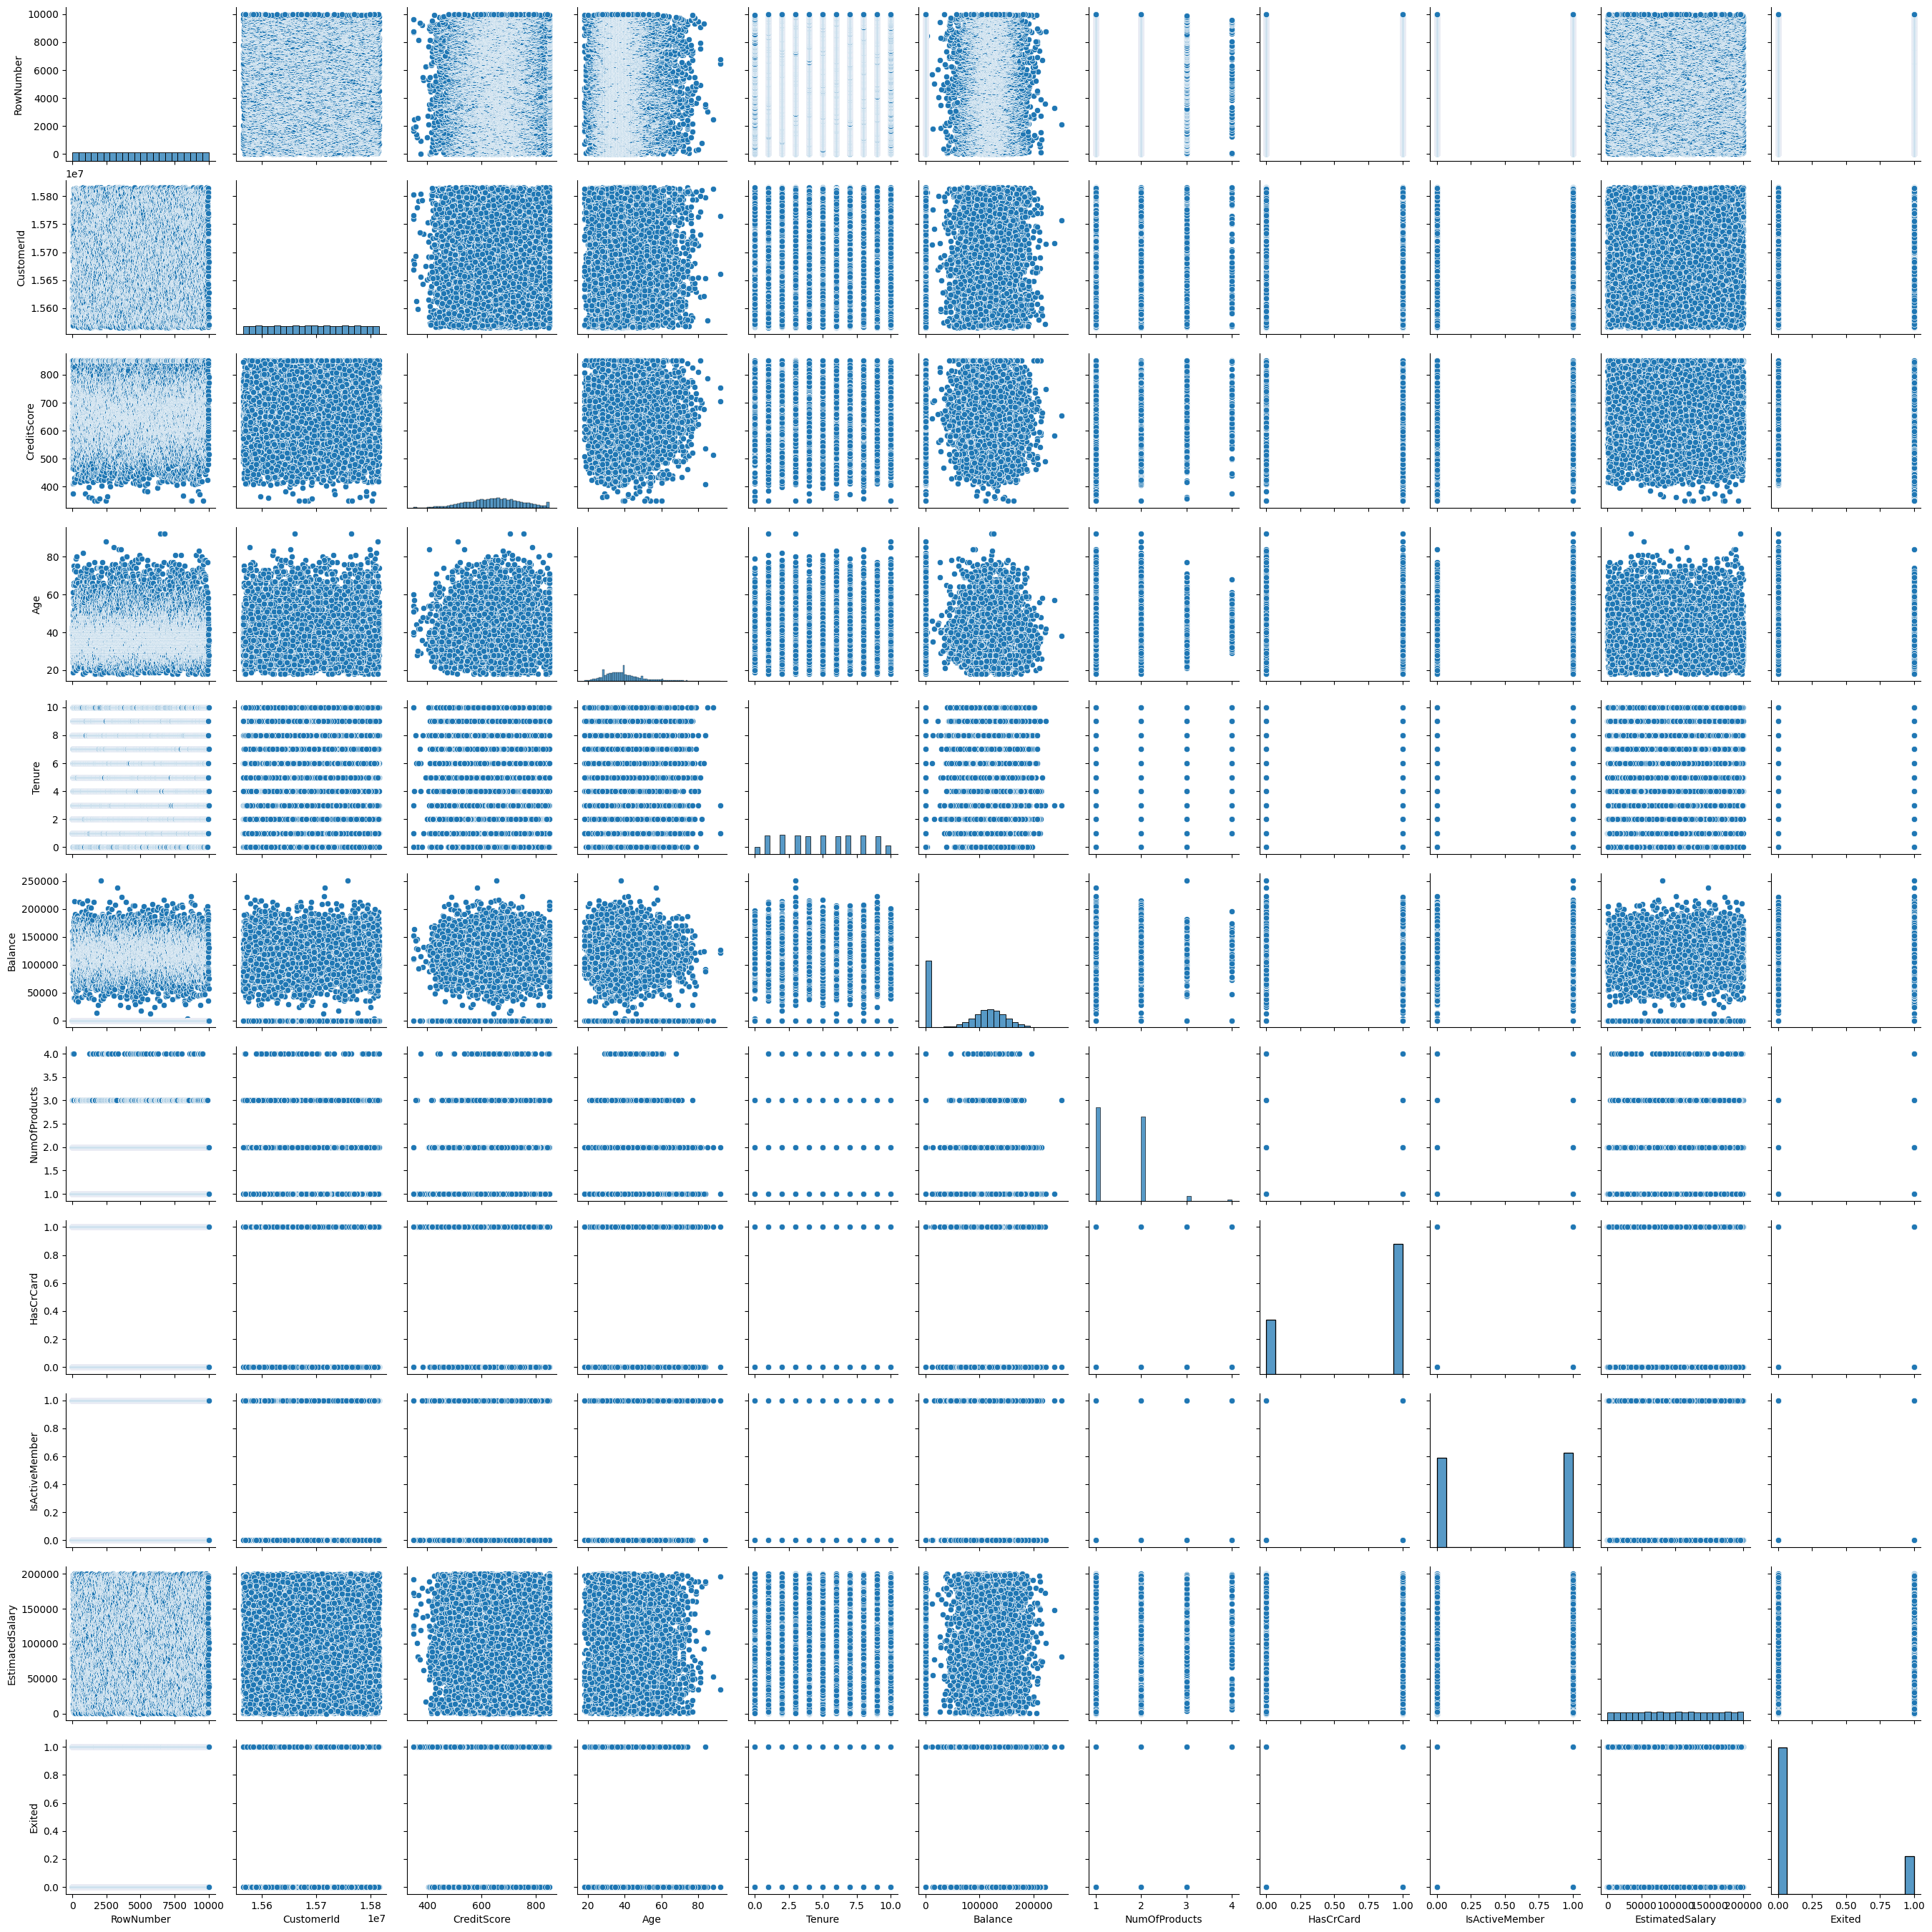

In [23]:
#Displaying scatter plots
sns.pairplot(data=df)

In [24]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


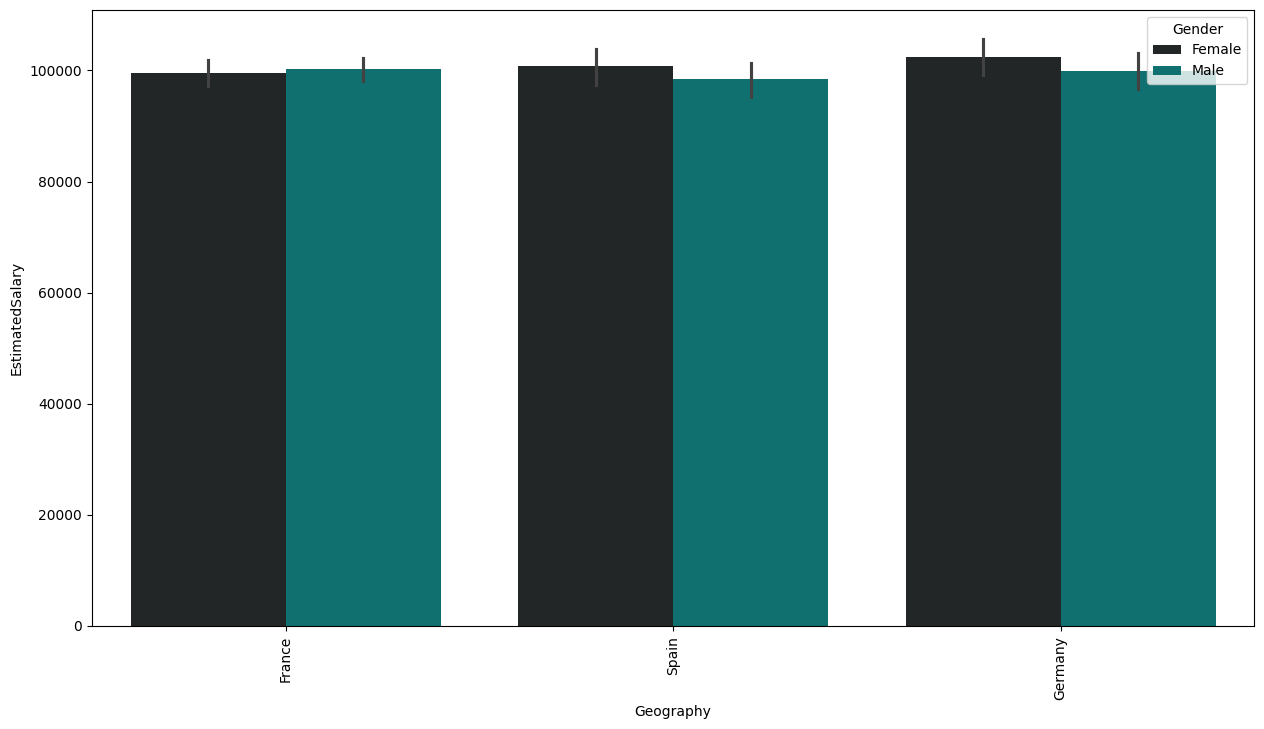

In [25]:
#Visualizing barplot where Geography is on x-axis and estimated salary is on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='Geography',y='EstimatedSalary',hue='Gender',color='teal',data=df);

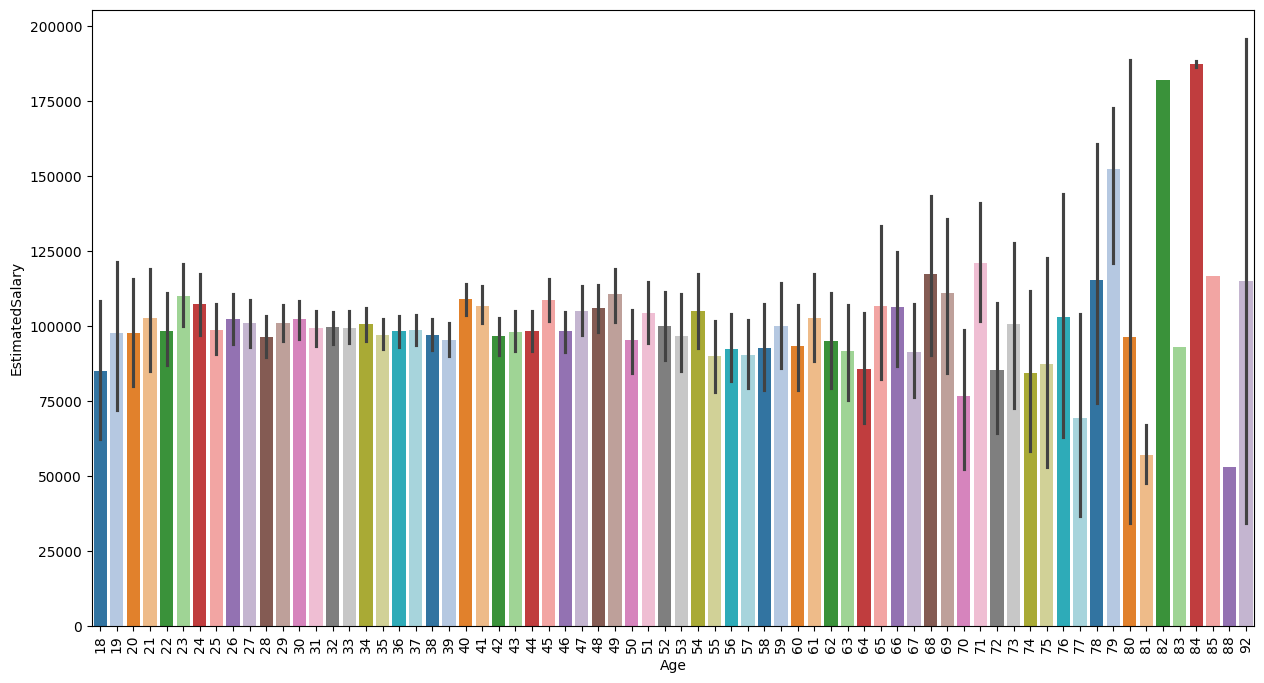

In [26]:
#Visualizing barplot where age is taken on x axis and estimated salary is taken on y axis
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='Age',y='EstimatedSalary',data=df,
    palette='tab20',
    legend=False);

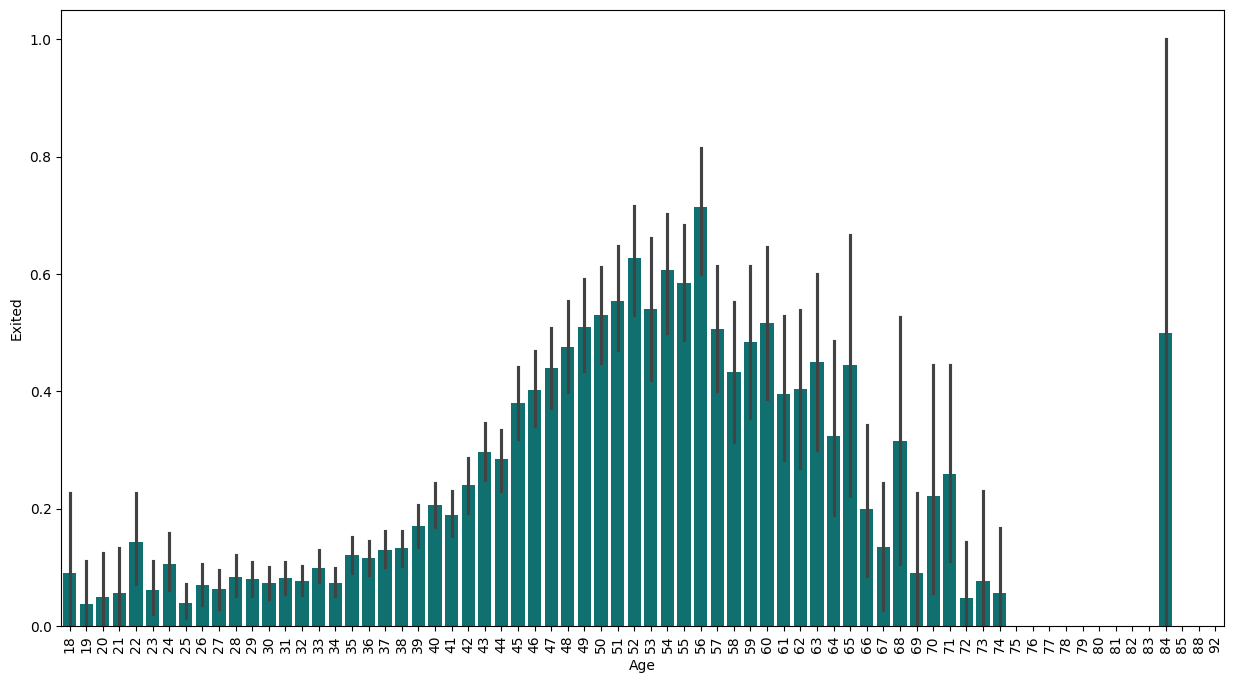

In [27]:
#Visualizing barplot where age is taken on x axis and exited in on y axis
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='Age',y='Exited',color='teal',data=df);

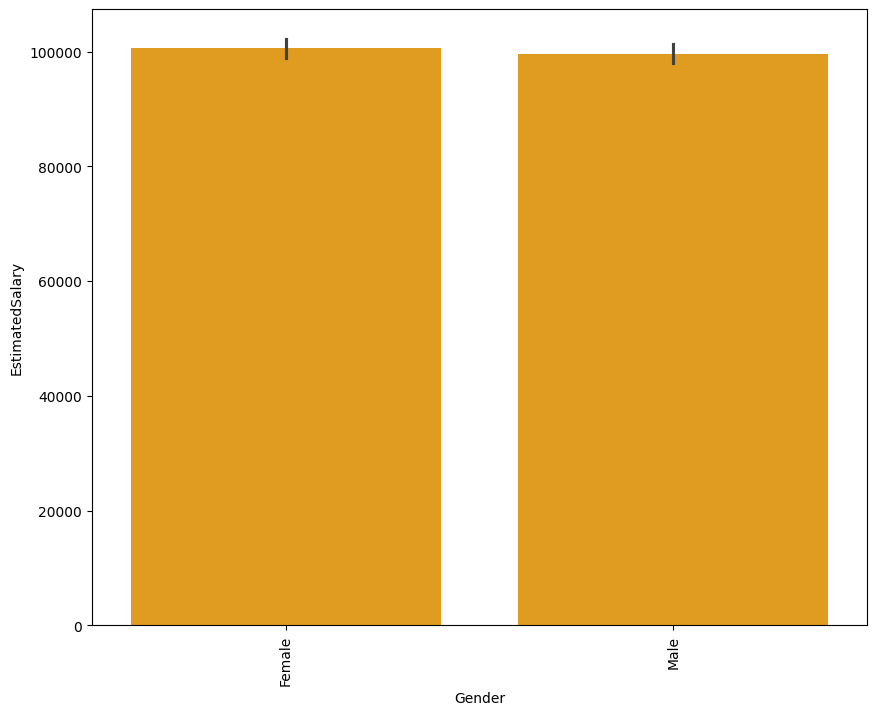

In [28]:
#Visualizing barplot where gender is taken on x axis and estimated salary is taken on y axis
plt.figure(figsize=(10, 8))
plt.xticks(rotation=90)
sns.barplot(x='Gender',y='EstimatedSalary',color='orange',data=df);

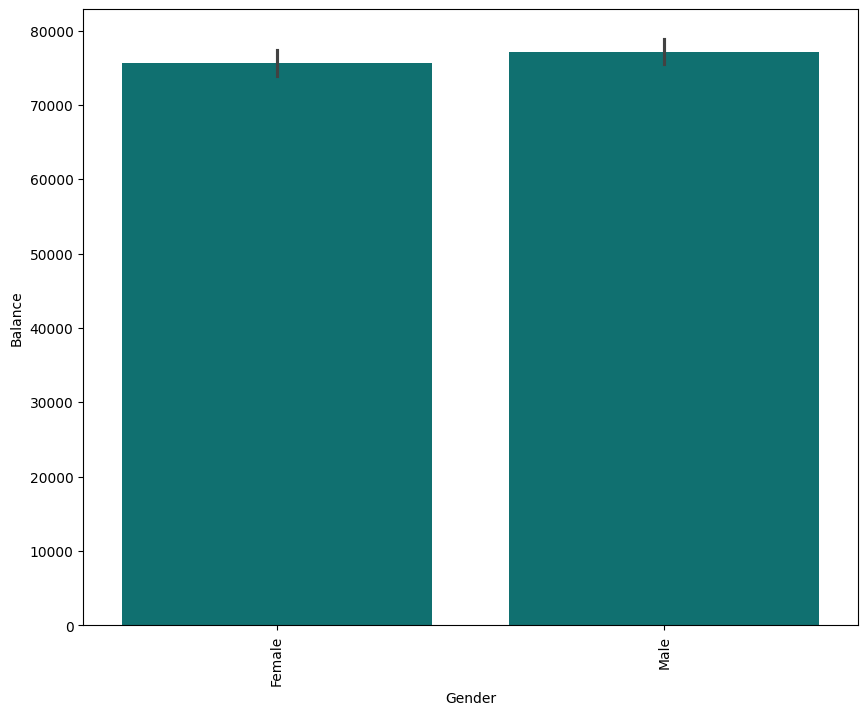

In [29]:
#Visualizing barplot where Gender is taken on x axis and Balance is taken on y axis
plt.figure(figsize=(10, 8))
plt.xticks(rotation=90)
sns.barplot(x='Gender',y='Balance',color='teal',data=df);

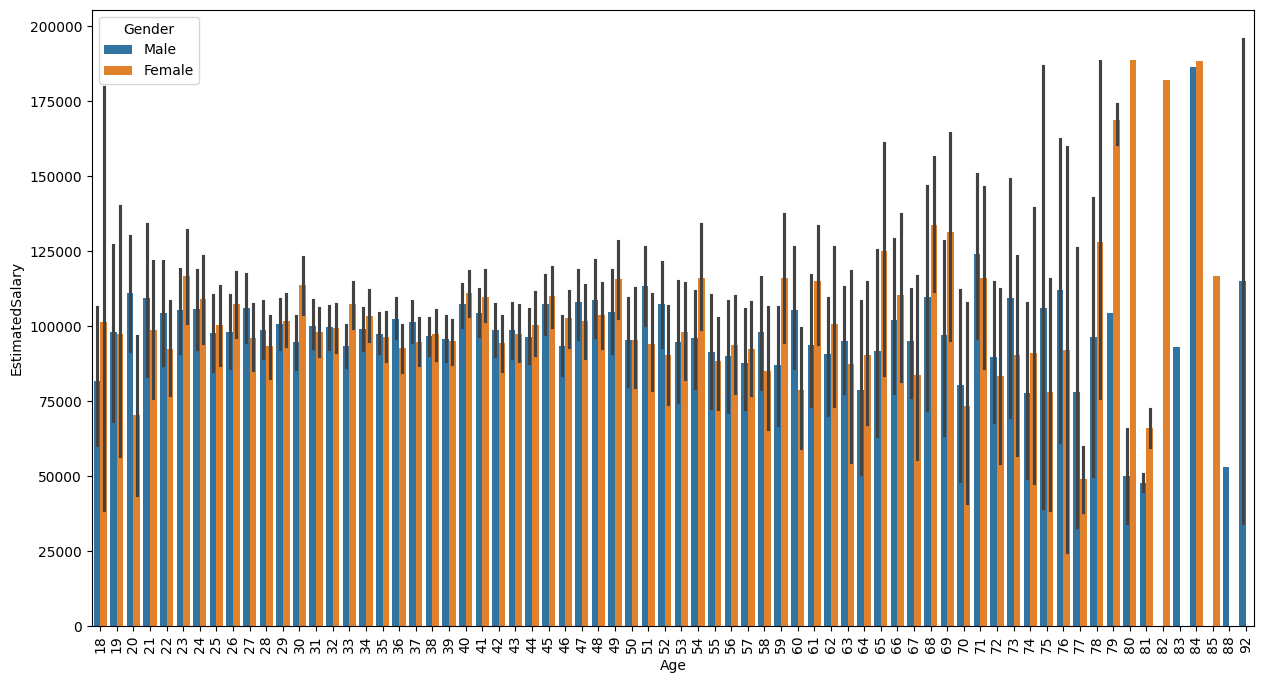

In [30]:
#Visualizing barplot where Age is taken on x axis and EstimatedSalary is taken on y axis
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='Age',y='EstimatedSalary',hue='Gender',data=df);

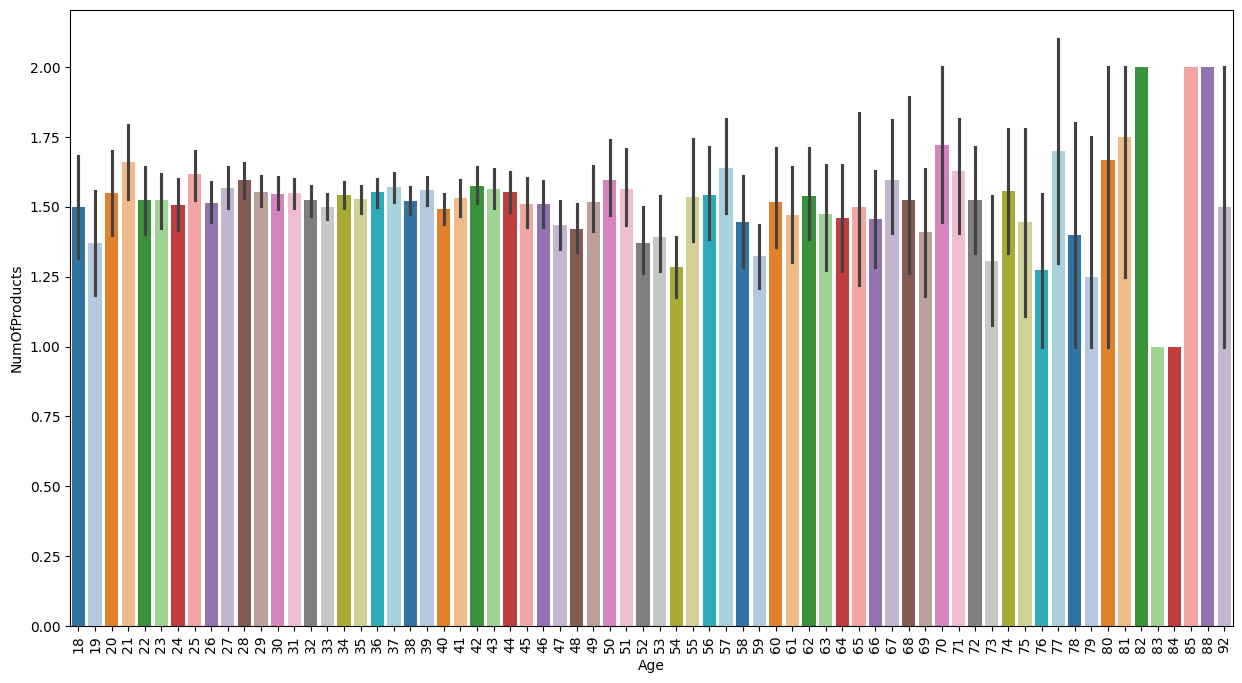

In [31]:
#Visualizing barplot where Age is taken on x axis and NumOfProducts is taken on y axis
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='Age',y='NumOfProducts',data=df,palette='tab20',
    legend=False);

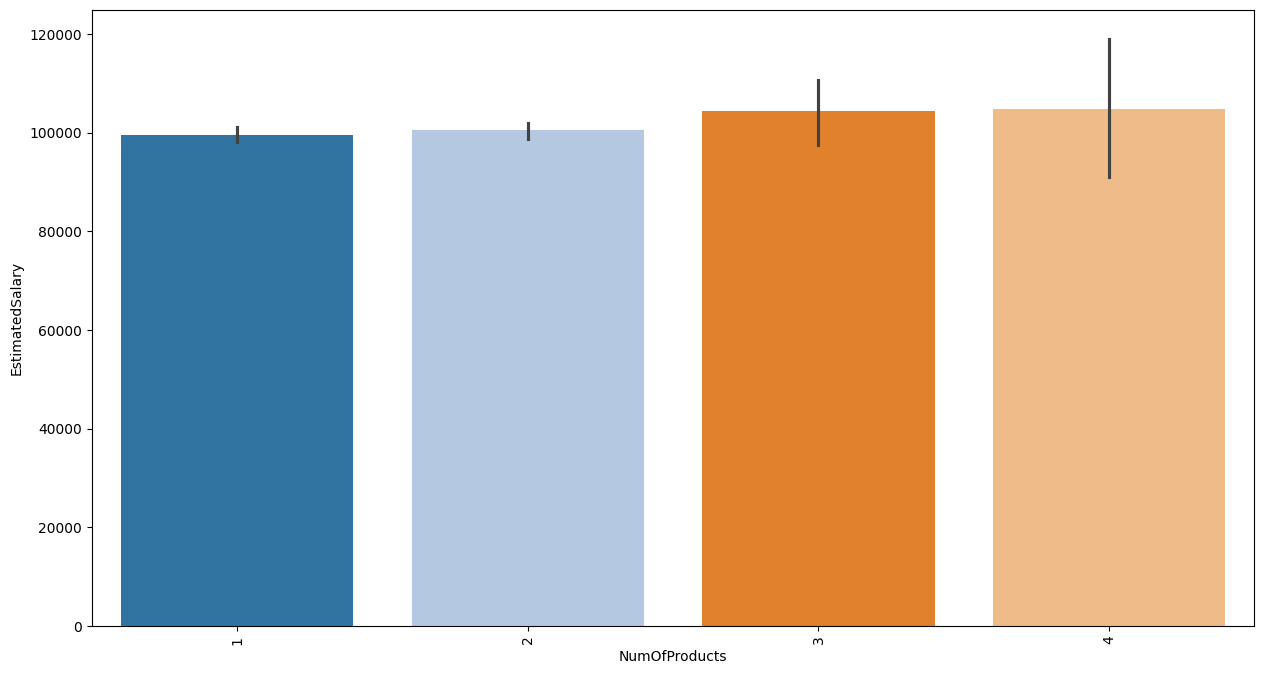

In [16]:
#Visualizing barplot where NumOfProducts is taken on x axis and EstimatedSalary is taken on y axis
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='NumOfProducts',y='EstimatedSalary',data=df,palette='tab20',
    legend=False);

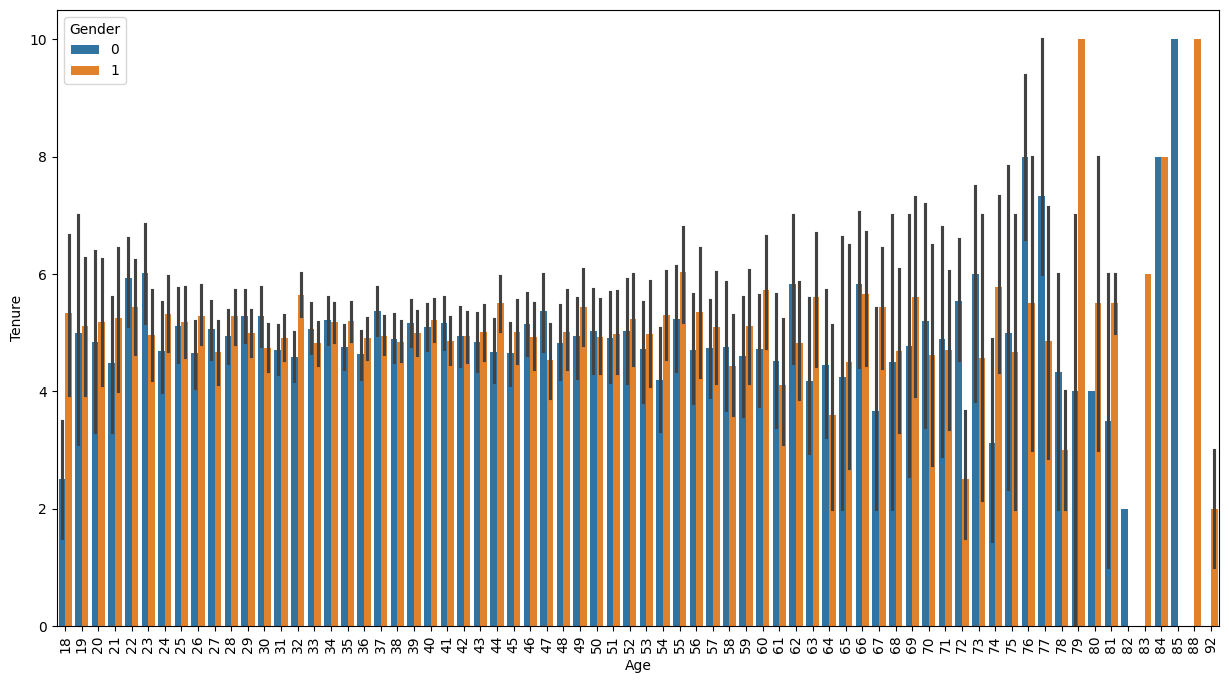

In [17]:
#Visualizing barplot where Age is taken on x axis and Tenure is taken on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='Age',y='Tenure',hue='Gender',data=df);

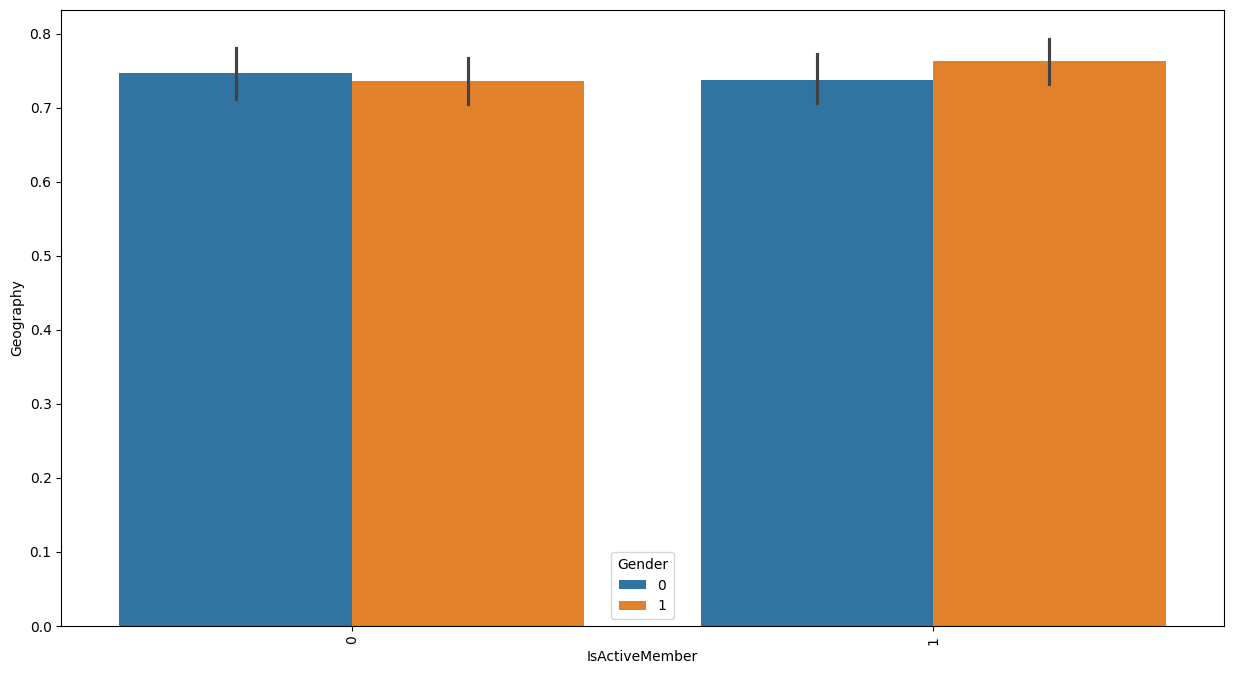

In [18]:
#Visualizing barplot where IsActiveMember is taken on x axis and Geography is taken on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='IsActiveMember',y='Geography',hue='Gender',data=df);

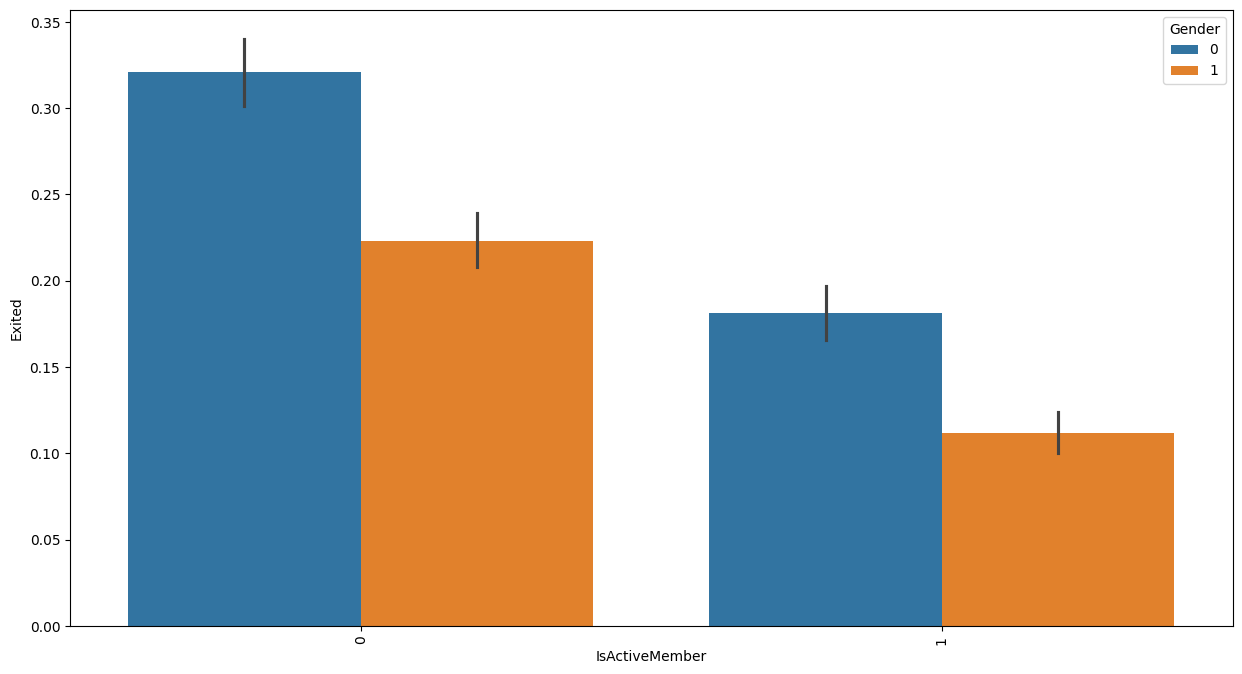

In [19]:
#Visualizing barplot where IsActiveMember is taken on x axis and Exited is taken on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='IsActiveMember',y='Exited',hue='Gender',data=df);

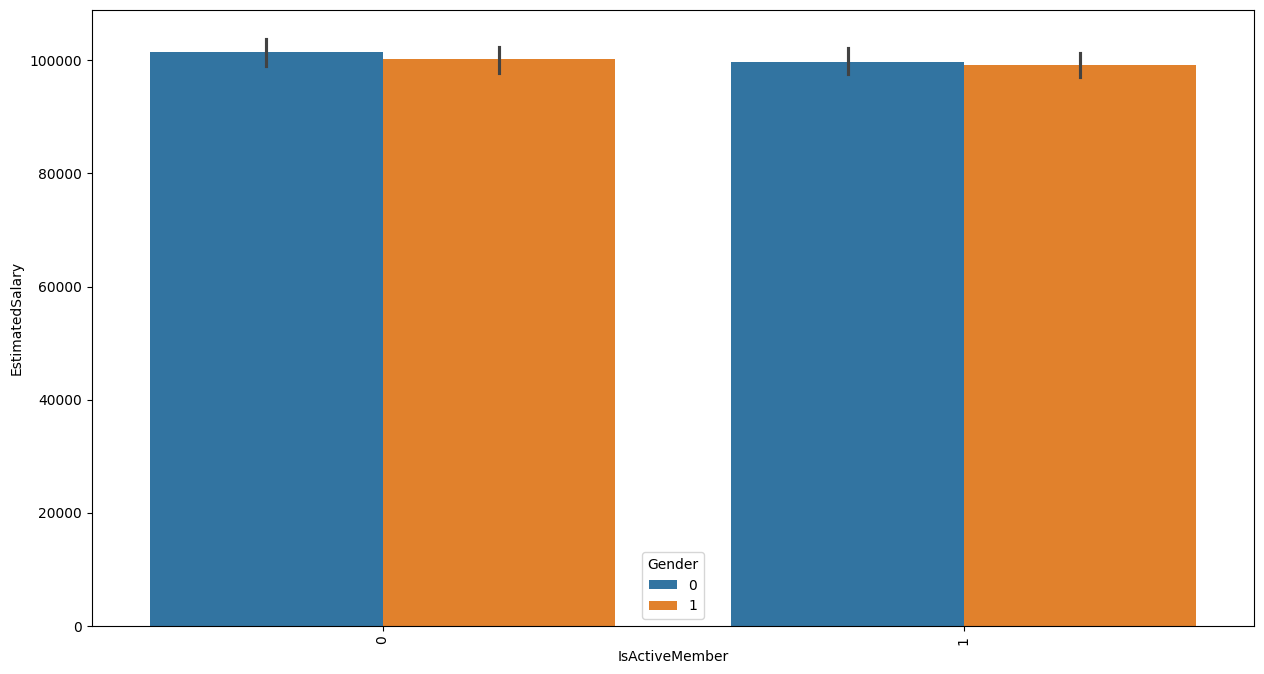

In [20]:
#Visualizing barplot where IsActiveMember is taken on x axis and EstimatedSalary is taken on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='IsActiveMember',y='EstimatedSalary',hue='Gender',data=df);

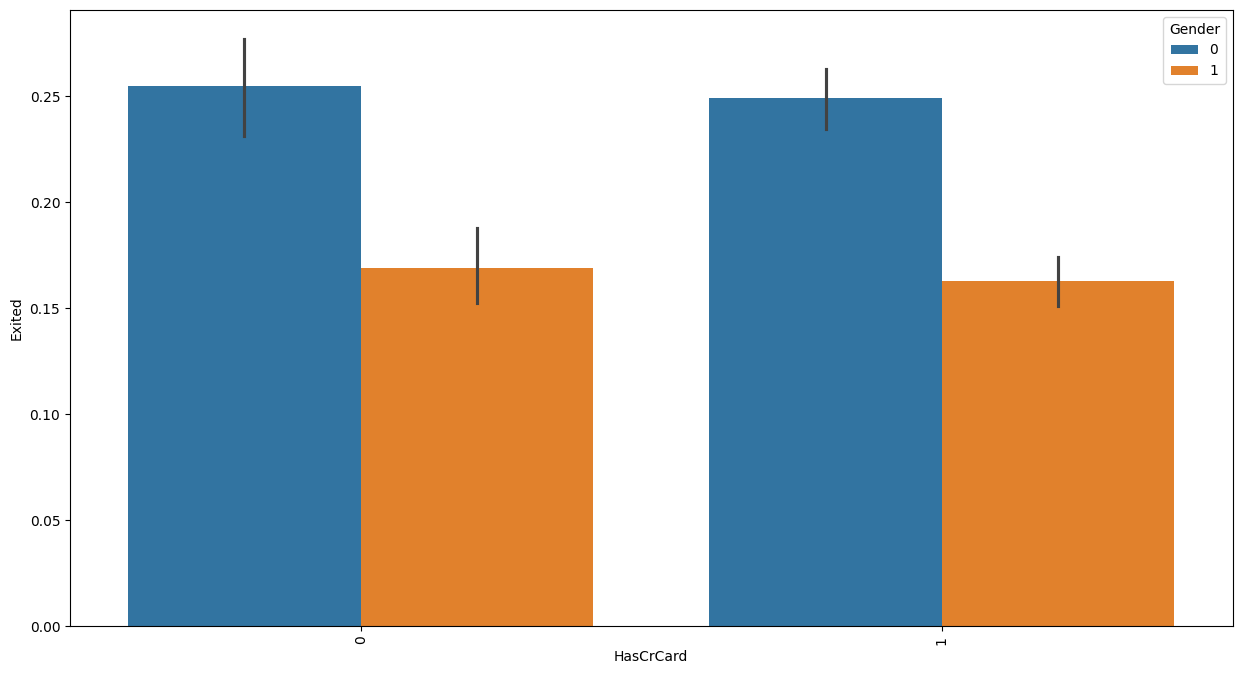

In [21]:
#Visualizing barplot where HasCrCard is taken on x axis and Exited is taken on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='HasCrCard',y='Exited',hue='Gender',data=df);

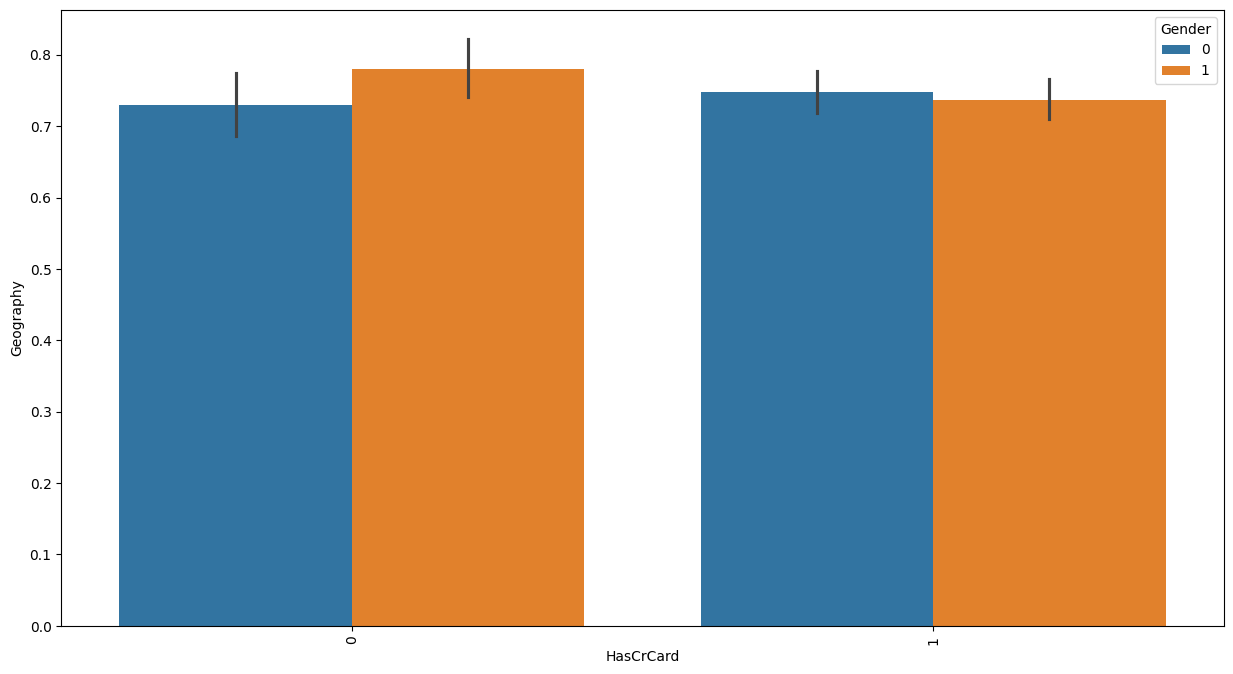

In [22]:
#Visualizing barplot where HasCrCard is taken on x axis and Geography is taken on y axis and key is gender
plt.figure(figsize=(15, 8))
plt.xticks(rotation=90)
sns.barplot(x='HasCrCard',y='Geography',hue='Gender',data=df);

## Label Encoding 

In [5]:
#Convert categorical data into numeric data
cat_cols=['Geography','Gender']
le=LabelEncoder()
for i in cat_cols:
    df[i]=le.fit_transform(df[i])
df.dtypes    

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [6]:
df.keys()

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
#Dropping uneccessary columns and removing them from the dataset 
df.drop(['RowNumber'],axis=1,inplace=True)
df.drop(['CustomerId'],axis=1,inplace=True)
df.drop(['Surname'],axis=1,inplace=True)

## DistributionPlot 

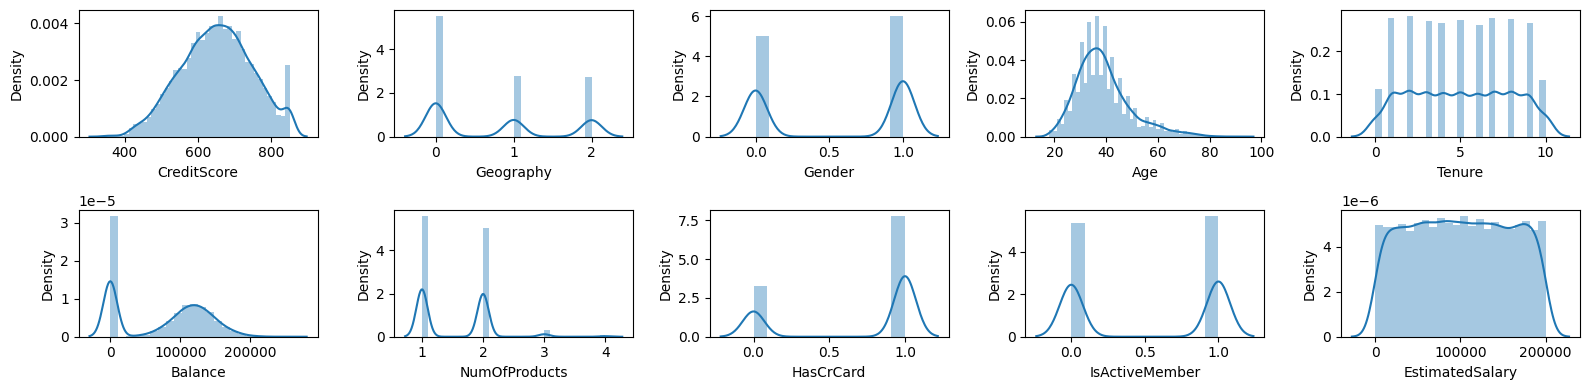

In [35]:
#Distribution plot will help us to check if the data is skewed or not
rows=2
cols=5
fig, ax=plt.subplots(nrows=rows,ncols=cols,figsize=(16,4))
col=df.columns
index=0
for i in range(rows):
    for j in range(cols):
        sns.distplot(df[col[index]],ax=ax[i][j])
        index=index+1
        
plt.tight_layout()

In [8]:
X=df.drop(labels=['Exited'],axis=1)
Y=df['Exited']
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [9]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [10]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=40)
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(8000, 10) (2000, 10) (8000,) (2000,)


### Logistic Regression

In [ ]:
#Fit the model on train data 
log_reg = LogisticRegression().fit(X_train, Y_train)

#Predict on train 
train_preds = log_reg.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds))

#Predict on test
test_preds = log_reg.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds))
print('Wrong predictions out of total')
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds).sum(),'/',((Y_test == test_preds).sum()+(Y_test != test_preds).sum()))
print('-'*50)

#Kappa Score.
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds))

Model accuracy on train is:  0.792375
Model accuracy on test is:  0.7995
--------------------------------------------------
ROC score on train is:  0.5678228878727736
ROC score on test is:  0.5711762582508251
--------------------------------------------------
confusion_matrix train is:  [[6033  314]
 [1347  306]]
confusion_matrix test is:  [[1522   94]
 [ 307   77]]
Wrong predictions out of total
--------------------------------------------------
401 / 2000
--------------------------------------------------
KappaScore is:  0.18052217699086115


### Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB
#Fit the model on train data 
NB=GaussianNB()
NB.fit(X_train,Y_train)

#Predict on train 
train_preds2 = NB.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds2))

#Predict on test
test_preds2 = NB.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds2))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds2))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds2))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds2))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds2))
print('Wrong predictions out of total')
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds2).sum(),'/',((Y_test == test_preds2).sum()+(Y_test != test_preds2).sum()))
print('-'*50)

#Kappa Score
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds2))

Model accuracy on train is:  0.781875
Model accuracy on test is:  0.7915
--------------------------------------------------
ROC score on train is:  0.5236234904696533
ROC score on test is:  0.5225479579207921
--------------------------------------------------
confusion_matrix train is:  [[6117  230]
 [1515  138]]
confusion_matrix test is:  [[1550   66]
 [ 351   33]]
Wrong predictions out of total
--------------------------------------------------
417 / 2000
--------------------------------------------------
KappaScore is:  0.0628876543875736


### Decision Tree Classifier

In [ ]:
#Fit the model on train data 
DT = DecisionTreeClassifier().fit(X,Y)

#Predict on train 
train_preds3 = DT.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds3))

#Predict on test
test_preds3 = DT.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds3))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds3))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds3))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds3))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds3))
print('Wrong predictions out of total')
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds3).sum(),'/',((Y_test == test_preds3).sum()+(Y_test != test_preds3).sum()))
print('-'*50)

#Kappa Score
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds3))

Model accuracy on train is:  1.0
Model accuracy on test is:  1.0
--------------------------------------------------
ROC score on train is:  1.0
ROC score on test is:  1.0
--------------------------------------------------
confusion_matrix train is:  [[6347    0]
 [   0 1653]]
confusion_matrix test is:  [[1616    0]
 [   0  384]]
Wrong predictions out of total
--------------------------------------------------
0 / 2000
--------------------------------------------------
KappaScore is:  1.0


### Random Forest Classifier

In [ ]:
#Fit the model on train data 
RF=RandomForestClassifier().fit(X_train,Y_train)
#Predict on train 
train_preds4 = RF.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds4))

#Predict on test
test_preds4 = RF.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds4))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds4))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds4))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds4))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds4))
print('Wrong predictions out of total')
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds4).sum(),'/',((Y_test == test_preds4).sum()+(Y_test != test_preds4).sum()))
print('-'*50)

#Kappa Score
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds4))

Model accuracy on train is:  1.0
Model accuracy on test is:  0.87
--------------------------------------------------
ROC score on train is:  1.0
ROC score on test is:  0.7279677186468647
--------------------------------------------------
confusion_matrix train is:  [[6347    0]
 [   0 1653]]
confusion_matrix test is:  [[1549   67]
 [ 193  191]]
Wrong predictions out of total
--------------------------------------------------
260 / 2000
--------------------------------------------------
KappaScore is:  0.521115138655586


### K-Nearest Neighbours

In [ ]:
#Fit the model on train data 
KNN = KNeighborsClassifier().fit(X_train,Y_train)
#Predict on train 
train_preds5 = KNN.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds5))

#Predict on test
test_preds5 = KNN.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds5))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds5))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds5))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds5))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds5))
print('Wrong predictions out of total')
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds5).sum(),'/',((Y_test == test_preds5).sum()+(Y_test != test_preds5).sum()))

print('-'*50)

#Kappa Score
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds5))

Model accuracy on train is:  0.8105
Model accuracy on test is:  0.7705
--------------------------------------------------
ROC score on train is:  0.5935625969407309
ROC score on test is:  0.5085602310231023
--------------------------------------------------
confusion_matrix train is:  [[6114  233]
 [1283  370]]
confusion_matrix test is:  [[1509  107]
 [ 352   32]]
Wrong predictions out of total
--------------------------------------------------
459 / 2000
--------------------------------------------------
KappaScore is:  0.022622353201710355


### Support Vector Machine

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn import metrics

#Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train Linear SVM (much faster)
SVM = LinearSVC(random_state=100, max_iter=5000)

SVM.fit(X_train_scaled, Y_train)

#Predict on train
train_preds6 = SVM.predict(X_train_scaled)
print("Model accuracy on train is:", accuracy_score(Y_train, train_preds6))

#Predict on test
test_preds6 = SVM.predict(X_test_scaled)
print("Model accuracy on test is:", accuracy_score(Y_test, test_preds6))
print('-'*50)

#ROC Score
print("ROC score on train is:", roc_auc_score(Y_train, train_preds6))
print("ROC score on test is:", roc_auc_score(Y_test, test_preds6))
print('-'*50)

#Confusion Matrix
print("Confusion Matrix (Train):")
print(confusion_matrix(Y_train, train_preds6))

print("Confusion Matrix (Test):")
print(confusion_matrix(Y_test, test_preds6))
print('-'*50)

#Recall
print("Recall:", metrics.recall_score(Y_test, test_preds6))
print('-'*50)

#Wrong Predictions
print("Wrong Predictions:",
      (Y_test != test_preds6).sum(), "/",
      len(Y_test))
print('-'*50)

#Kappa Score
print("Kappa Score:", metrics.cohen_kappa_score(Y_test, test_preds6))

Model accuracy on train is: 0.80025
Model accuracy on test is: 0.8125
--------------------------------------------------
ROC score on train is: 0.545046695015084
ROC score on test is: 0.5484478135313532
--------------------------------------------------
Confusion Matrix (Train):
[[6220  127]
 [1471  182]]
Confusion Matrix (Test):
[[1579   37]
 [ 338   46]]
--------------------------------------------------
Recall: 0.11979166666666667
--------------------------------------------------
Wrong Predictions: 375 / 2000
--------------------------------------------------
Kappa Score: 0.13818462613299998


### XG-Boost Classifier

In [ ]:
xgbr =xgb.XGBClassifier().fit(X_train, Y_train)

#Predict on train 
train_preds7 = xgbr.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds7))

#Predict on test
test_preds7 = xgbr.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds7))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds7))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds7))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds7))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds7))
print('Wrong predictions out of total')
print('-'*50)

print("recall", metrics.recall_score(Y_test, test_preds7))
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds7).sum(),'/',((Y_test == test_preds7).sum()+(Y_test != test_preds7).sum()))
print('-'*50)

#Kappa Score
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds7))

Model accuracy on train is:  0.95425
Model accuracy on test is:  0.8655
--------------------------------------------------
ROC score on train is:  0.8989114234437847
ROC score on test is:  0.7480146452145213
--------------------------------------------------
confusion_matrix train is:  [[6304   43]
 [ 323 1330]]
confusion_matrix test is:  [[1517   99]
 [ 170  214]]
Wrong predictions out of total
--------------------------------------------------
recall 0.5572916666666666
--------------------------------------------------
269 / 2000
--------------------------------------------------
KappaScore is:  0.5336403101205254


In [ ]:
#Random Forest Classifier and Xg-boost Regressor model performed well compared to other models

# Hyper Parameter Tuning

In [ ]:
#Fit the model on train data 
RFT=RandomForestClassifier(n_estimators=500,min_samples_split=2,min_samples_leaf=1,max_features='sqrt',random_state=235,verbose=2,max_samples=50).fit(X_train,Y_train)
#predict on train 
train_preds8 = RFT.predict(X_train)
#Accuracy on train
print("Model accuracy on train is: ", accuracy_score(Y_train, train_preds8))

#Predict on test
test_preds8 = RFT.predict(X_test)
#Accuracy on test
print("Model accuracy on test is: ", accuracy_score(Y_test, test_preds8))
print('-'*50)

#We got good accuracy which means our model is performing quite well 
#ROC 
print("ROC score on train is: ", roc_auc_score(Y_train, train_preds8))
print("ROC score on test is: ", roc_auc_score(Y_test, test_preds8))
print('-'*50)

#Confusion matrix
print("confusion_matrix train is: ", confusion_matrix(Y_train, train_preds8))
print("confusion_matrix test is: ", confusion_matrix(Y_test, test_preds8))
print('Wrong predictions out of total')
print('-'*50)

#Wrong Predictions made.
print((Y_test !=test_preds8).sum(),'/',((Y_test == test_preds8).sum()+(Y_test != test_preds8).sum()))
print('-'*50)

#Kappa Score
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,test_preds8))

building tree 1 of 500
building tree 2 of 500
building tree 3 of 500
building tree 4 of 500
building tree 5 of 500
building tree 6 of 500
building tree 7 of 500
building tree 8 of 500
building tree 9 of 500
building tree 10 of 500
building tree 11 of 500
building tree 12 of 500
building tree 13 of 500
building tree 14 of 500
building tree 15 of 500
building tree 16 of 500
building tree 17 of 500
building tree 18 of 500
building tree 19 of 500
building tree 20 of 500
building tree 21 of 500
building tree 22 of 500
building tree 23 of 500
building tree 24 of 500
building tree 25 of 500
building tree 26 of 500
building tree 27 of 500
building tree 28 of 500
building tree 29 of 500
building tree 30 of 500
building tree 31 of 500
building tree 32 of 500
building tree 33 of 500
building tree 34 of 500
building tree 35 of 500
building tree 36 of 500
building tree 37 of 500
building tree 38 of 500
building tree 39 of 500
building tree 40 of 500
building tree 41 of 500
building tree 42 of 500
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s


building tree 281 of 500
building tree 282 of 500
building tree 283 of 500
building tree 284 of 500
building tree 285 of 500
building tree 286 of 500
building tree 287 of 500
building tree 288 of 500
building tree 289 of 500
building tree 290 of 500
building tree 291 of 500
building tree 292 of 500
building tree 293 of 500
building tree 294 of 500
building tree 295 of 500
building tree 296 of 500
building tree 297 of 500
building tree 298 of 500
building tree 299 of 500
building tree 300 of 500
building tree 301 of 500
building tree 302 of 500
building tree 303 of 500
building tree 304 of 500
building tree 305 of 500
building tree 306 of 500
building tree 307 of 500
building tree 308 of 500
building tree 309 of 500
building tree 310 of 500
building tree 311 of 500
building tree 312 of 500
building tree 313 of 500
building tree 314 of 500
building tree 315 of 500
building tree 316 of 500
building tree 317 of 500
building tree 318 of 500
building tree 319 of 500
building tree 320 of 500


[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s


Model accuracy on train is:  0.817375
Model accuracy on test is:  0.833
--------------------------------------------------
ROC score on train is:  0.5627739872818145
ROC score on test is:  0.5720529084158417
--------------------------------------------------
confusion_matrix train is:  [[6326   21]
 [1440  213]]
confusion_matrix test is:  [[1609    7]
 [ 327   57]]
Wrong predictions out of total
--------------------------------------------------
334 / 2000
--------------------------------------------------
KappaScore is:  0.21119256348246673


[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 364 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:    0.0s finished


### A. RandomSearchCv

In [13]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
random_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

rf_randomcv = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=100),
    param_distributions=random_grid,
    n_iter=10,
    cv=3,
    random_state=100,
    verbose=2,
    n_jobs=-1
)

rf_randomcv.fit(X_train, Y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestC...dom_state=100)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,100
,error_score,nan


In [25]:
print(X_train.shape)

(8000, 10)


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

RFT1 = RandomForestClassifier(random_state=100)

rf_randomcv = RandomizedSearchCV(
    estimator=RFT1,
    param_distributions=random_grid,
    n_iter=10,      # Reduced from 100
    cv=3,           # Reduced from 5
    random_state=100,
    n_jobs=-1,
    verbose=2
)

rf_randomcv.fit(X_train, Y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestC...dom_state=100)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,100
,error_score,nan


In [ ]:
rf_randomcv.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 30,
 'criterion': 'gini'}

In [ ]:
rf_randomcv

,estimator,RandomForestC...dom_state=100)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,100
,error_score,nan


In [ ]:
rf_randomcv.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
#Saving all parameters in best_random_grid
best_random_grid=rf_randomcv.best_estimator_

In [ ]:
Y_pred=best_random_grid.predict(X_test)

print(confusion_matrix(Y_test,Y_pred))
print("Accuracy Score {}".format(accuracy_score(Y_test,Y_pred)))

#Wrong Predictions made.
print((Y_test !=Y_pred).sum(),'/',((Y_test == Y_pred).sum()+(Y_test != Y_pred).sum()))
print('-'*50)

#Kappa Score
#Predicting the randomised search cv models parameters and evaluating the random forest model using evaluation metrics
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,Y_pred))

[[1559   57]
 [ 191  193]]
Accuracy Score 0.876
248 / 2000
--------------------------------------------------
KappaScore is:  0.5390334572490707


### B. GridSearchCv

In [ ]:
#Using grid search cv model
from sklearn.model_selection import GridSearchCV

In [ ]:
#Visualizing the best parameters of random cv
rf_randomcv.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 30,
 'criterion': 'gini'}

In [ ]:
#Creating a param_grid
param_grid = {
    'criterion': [rf_randomcv.best_params_['criterion']],
    'max_depth': [rf_randomcv.best_params_['max_depth']],
    'max_features': [rf_randomcv.best_params_['max_features']],
    'min_samples_leaf': [rf_randomcv.best_params_['min_samples_leaf'], 
                         rf_randomcv.best_params_['min_samples_leaf']+2, 
                         rf_randomcv.best_params_['min_samples_leaf'] + 4],
    'min_samples_split': [rf_randomcv.best_params_['min_samples_split'] - 2,
                          rf_randomcv.best_params_['min_samples_split'] - 1,
                          rf_randomcv.best_params_['min_samples_split'], 
                          rf_randomcv.best_params_['min_samples_split'] +1,
                          rf_randomcv.best_params_['min_samples_split'] + 2],
    'n_estimators': [rf_randomcv.best_params_['n_estimators'] - 200, rf_randomcv.best_params_['n_estimators'] - 100, 
                     rf_randomcv.best_params_['n_estimators'], 
                     rf_randomcv.best_params_['n_estimators'] + 100, rf_randomcv.best_params_['n_estimators'] + 200]
}

print(param_grid)

{'criterion': ['gini'], 'max_depth': [30], 'max_features': ['sqrt'], 'min_samples_leaf': [2, 4, 6], 'min_samples_split': [3, 4, 5, 6, 7], 'n_estimators': [-100, 0, 100, 200, 300]}


In [ ]:
rf = RandomForestClassifier(random_state=100)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, Y_train)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


,estimator,RandomForestC...dom_state=100)
,param_grid,"{'criterion': ['gini'], 'max_depth': [30], 'max_features': ['sqrt'], 'min_samples_leaf': [2, 4, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [45]:
print(grid_search)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=100),
             n_jobs=-1,
             param_grid={'criterion': ['gini'], 'max_depth': [30],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [3, 4, 5, 6, 7],
                         'n_estimators': [-100, 0, 100, 200, 300]},
             verbose=2)


In [46]:
best_rf = rf_randomcv.best_estimator_

In [47]:
print(rf_randomcv.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'gini'}


In [ ]:
#Saving the parameters in best_grid
best_grid=grid_search.best_estimator_

In [ ]:
best_grid

,n_estimators,100
,criterion,'gini'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred=best_grid.predict(X_test)
print(confusion_matrix(Y_test,y_pred))
print("Accuracy Score {}".format(accuracy_score(Y_test,y_pred)))

#Wrong Predictions made.
print((Y_test !=y_pred).sum(),'/',((Y_test == y_pred).sum()+(Y_test != y_pred).sum()))
print('-'*50)

#Kappa Score
#Predicting the grid search cv on random forest model
print('KappaScore is: ', metrics.cohen_kappa_score(Y_test,y_pred))

[[1559   57]
 [ 191  193]]
Accuracy Score 0.876
248 / 2000
--------------------------------------------------
KappaScore is:  0.5390334572490707
